[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jecampagne/nufftcf/blob/main/notebook/scipy_vs_nufftcf_ccf.ipynb)


# Cross-correlation: `scipy.signal.correlate` vs `nufftcf`

Using this notebook, the user familiar with scipy tools,  will learn how to handle the nufftcf functions on a deliberately simple example not represantattive of real experimenatl case but rather in the spirit of the [scipy correlate toy example](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlate.html).

We show how the cross-correlation function (CCF) of two regularly-sampled series can be computed with

| Method | Package | Algorithm | Kernel |
|--------|---------|-----------|--------|
| **scipy direct** | `scipy.signal.correlate(..., method="direct")` | sum over all pairs, $O(N^2)$ | none (raw lags) |
| **scipy FFT** | `scipy.signal.correlate(..., method="fft")` | FFT + zero padding, $O(N\log N)$ | none (raw lags) |
| **nufftcf FFT** | `nufftcf.compute_ccf_rectangle_fft` | FFT cross-correlation + Wiener-Khinchin | rectangle (`bin_width`) |
| **nufftcf NUFFT** | `nufftcf.compute_ccf_rectangle_nufft` | NUFFT + Wiener-Khinchin | rectangle (`bin_width`) |




**Test case.** $x(t)=\sin(2\pi t/128)$ sampled at $t=0,\dots,127$, and $y(t)=\sin\!\big(2\pi (t-\tau_0)/128\big)+\text{noise}$,
i.e. a copy of $x$ delayed by $\tau_0 = 0.2 \times 128 = 25.6$ samples and corrupted by Gaussian noise
($\sigma=0.2$). The CCF should peak at $\tau=\tau_0$.

**Conventions.**
- A *positive lag* means that `y` lags behind `x` (same convention in `scipy.signal.correlate(y, x)` and in `nufftcf`).
- `nufftcf` returns a **Pearson** CCF (both series are standardized internally). To compare with SciPy we therefore
  standardize the inputs ourselves and divide the raw SciPy output by the number of overlapping pairs at each lag.
- The four estimates are almost identical, so overlaying them in a single plot is not informative.
  We instead quantify the differences in a **table of errors, taking `scipy` `method="direct"` as the reference**.

An analysis of the peak value >1 and how the **N1** parameter, one of the internal  nufftcf parameters, can influence the result,  leads to some takeaway messages.

In [ ]:
%pip install -q "nufftcf>=0.2.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 66.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

import nufftcf
from nufftcf import compute_ccf_rectangle_fft, compute_ccf_rectangle_nufft, compute_ccf_rectangle_realspace

print(f"nufftcf : {nufftcf.__version__}")
print(f"numpy   : {np.__version__}")
print(f"scipy   : {__import__('scipy').__version__}")

nufftcf : 0.2.1
numpy   : 2.1.3
scipy   : 1.16.3


In [ ]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.size'         : 13,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 14,
    'xtick.labelsize'   : 14,
    'ytick.labelsize'   : 14,
    'legend.fontsize'   : 12,
    'figure.titlesize'  : 16,
    'figure.titleweight': 'bold',
})

# 1. Test series

`sig` is the reference sine (period 128 samples). `sig_noise` is the same sine delayed by `Dt = 25.6` samples
(a non-integer delay, so the true peak falls between two lags of the integer grid) plus Gaussian noise.
The random seed is fixed so that the numbers below are reproducible.

In [ ]:
rng = np.random.default_rng(42)

ts = np.arange(128)                 # regular sampling, dt = 1
n = len(ts)
period = 128
Dt = 0.2 * period                   # true delay = 25.6 samples

sig = np.sin(2 * np.pi * ts / period)
sig_noise = np.sin(2 * np.pi * (ts - Dt) / period) + 0.2 * rng.standard_normal(n)

print(f"true delay Dt = {Dt}")

true delay Dt = 25.6


# 2. SciPy: `direct` and `fft` methods

`scipy.signal.correlate(a, b, mode="full")` returns the raw sum $\sum_n a[n+k]\,b[n]$ for each lag $k$.
To turn it into a Pearson-type estimate that is comparable to `nufftcf`:

1. standardize both series (zero mean, unit variance),
2. divide by the exact number of overlapping pairs $N-|k|$ at each lag (and not by e.g. `max()`).

The lag axis is given by `signal.correlation_lags`.

In [ ]:
def standardize(x):
    """Zero-mean, unit-variance standardization -- same convention nufftcf
    uses internally, needed so the two normalisations agree."""
    return (x - np.mean(x)) / np.std(x)

sig_std = standardize(sig)
sig_noise_std = standardize(sig_noise)

# lags and exact overlap-pair count per lag (two equal-length series, "full" mode)
lags = signal.correlation_lags(n, n)
npairs = n - np.abs(lags)

corr_direct = signal.correlate(sig_noise_std, sig_std, mode="full", method="direct") / npairs
corr_fft    = signal.correlate(sig_noise_std, sig_std, mode="full", method="fft")    / npairs

# 3. `nufftcf`: rectangle kernel, FFT and NUFFT versions

Both functions take the lags, then `(t, x)` and `(s, y)` for the two series (here the sampling times are the same),
and return `(c, b)`: the CCF estimate and the effective pair count per lag. Standardization is done internally.

With `bin_width = 0.5` (smaller than the sampling step `dt = 1`) the rectangular kernel contains a single lag of
the grid, so no extra smoothing is applied and the estimate is directly comparable to the raw pair-normalized
correlation computed with SciPy above.

In [ ]:
lags_f = lags.astype(float)

c_rect_fft,   b_rect_fft   = compute_ccf_rectangle_fft(  lags_f, ts, sig, ts, sig_noise, bin_width=0.5)
c_rect_nufft, b_rect_nufft = compute_ccf_rectangle_nufft(lags_f, ts, sig, ts, sig_noise, bin_width=0.5)
c_rect_realspace, _ = compute_ccf_rectangle_realspace(lags_f, ts, sig, ts, sig_noise, bin_width=0.5)

# 4. Visual comparison

Left: the two input series. Middle: the two SciPy estimates. Right: the two `nufftcf` estimates. The vertical dashed line marks the true delay. The estimates depart from the noise-free curve (noise, finite record length) and become less reliable at large $|\tau|$ where few pairs overlap.

As expected the curves in each panel lie on top of each other (and on top of the other panel's curves):
see the next section for a quantitative comparison.

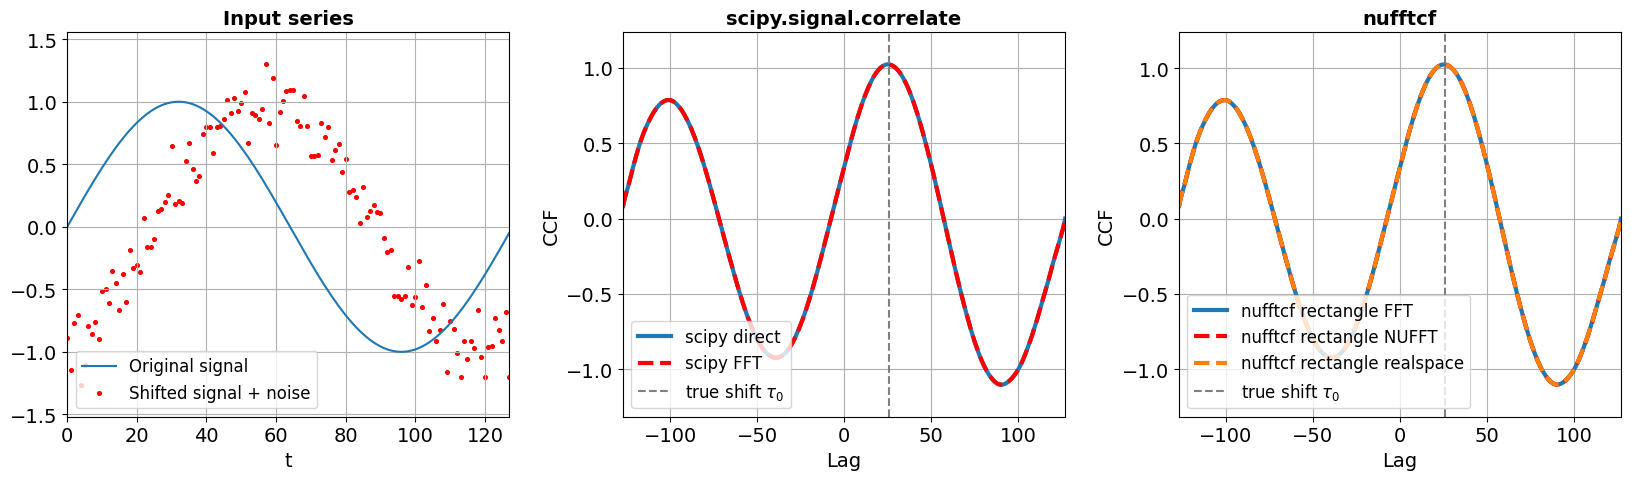

In [ ]:
fig, (ax_data, ax_sp, ax_nf) = plt.subplots(1, 3, figsize=(3 * 5.5, 5))

# --- input series
ax_data.plot(ts, sig, label='Original signal')
ax_data.scatter(ts, sig_noise, label='Shifted signal + noise', s=7, c="red")
ax_data.set_xlabel('t')
ax_data.set_title('Input series')
ax_data.legend()

# --- scipy
ax_sp.plot(lags, corr_direct, lw=3, label="scipy direct")
ax_sp.plot(lags, corr_fft, ls="--", c="red", lw=3, label="scipy FFT")
ax_sp.set_title('scipy.signal.correlate')

# --- nufftcf
ax_nf.plot(lags, c_rect_fft, lw=3, label="nufftcf rectangle FFT")
ax_nf.plot(lags, c_rect_nufft, ls="--", c="red", lw=3, label="nufftcf rectangle NUFFT")
ax_nf.plot(lags, c_rect_realspace, ls="--", lw=3, label="nufftcf rectangle realspace")
ax_nf.set_title('nufftcf')

for ax in (ax_sp, ax_nf):
    ax.axvline(Dt, ls="--", c="gray", label=r"true shift $\tau_0$")
    ax.set_xlabel('Lag')
    ax.set_ylabel('CCF')

for ax in (ax_data, ax_sp, ax_nf):
    ax.margins(0, 0.1)
    ax.grid()
    ax.legend(loc="lower left" if ax is not ax_data else "best")

fig.tight_layout()
plt.show()

# 5. Quantitative comparison: errors w.r.t. `scipy` direct

We take `scipy.signal.correlate(..., method="direct")` (exact sum over all pairs) as the reference and report,
for each method, the maximum and RMS absolute difference over all lags, and the location of the CCF maximum
(on the integer lag grid, the true delay being 25.6).


In [ ]:
estimates = {
    "scipy FFT":                corr_fft,
    "nufftcf rectangle realspace": c_rect_realspace,
    "nufftcf rectangle FFT":    c_rect_fft,
    "nufftcf rectangle NUFFT":  c_rect_nufft,
}

rows = []
for name, c in estimates.items():
    err = np.abs(c - corr_direct).   # scypy direct is the reference
    imax = np.argmax(c)
    rows.append({
        "method": name,
        "max |err|": f"{err.max():.2e}",
        "imax":f"{imax}",
        "RMS err": f"{np.sqrt(np.mean(err**2)):.2e}",
        "peak lag": lags[imax],
        "peak value": f"{c[imax]:.4f}",
    })

pd.DataFrame(rows).set_index("method")

,max |err|,imax,RMS err,peak lag,peak value
method,,,,,
scipy FFT,1.07e-14,152,8.34e-16,25,1.0240
nufftcf rectangle realspace,9.99e-16,152,3.26e-16,25,1.0240
nufftcf rectangle FFT,1.39e-17,152,9.02e-19,25,1.0240
nufftcf rectangle NUFFT,9.95e-04,152,4.95e-04,25,1.0248


## Peak value >1

Note that the peak value can slightly exceed 1.

Both series are standardized
once, globally (mean 0, variance 1 over the full record) -- not re-standardized
on the specific subset of samples that overlap at each lag. If that subset's
own local mean and variance happen to deviate from the global ones (pure
sampling/noise effect, unavoidable for a finite record), the pair-count-normalized
product can exceed 1 even though the *local* Pearson correlation -- recomputed
by re-standardizing on that subset alone -- never does.

At lag=25, the correlation (scipy or the others) compare the sig and sig_noise series with 103 pares, i.e. sig_std[0:103] and sig_noise_std[25:128], if we recompute the Pearson coefficient in this context, one recover a value <1.

In [ ]:
imax_diff = 152 # see table above
n_paires = int(b_rect_fft[imax_diff])
print("number of pairs:",n_paires)

lag_max = lags[imax]
x_ = sig_std[0:n_paires]
y_ = sig_noise_std[lag_max:lag_max+n_paires]

# the global mean and std of sig_std and sig_noise_std are 0 and 1 by definitions
print(f"local x mean/std:  {x_.mean():.6f}, {x_.std():.6f}")
print(f"local y mean/std:  {y_.mean():.6f}, {y_.std():.6f}")

Pearson_local = (corr_fft[imax_diff] -  x_.mean()*y_.mean())/(x_.std() * y_.std())
print(f"Pearson local; {Pearson_local:.4f}")


number of pairs: 103
local x mean/std:  0.191905, 1.008589
local y mean/std:  0.193039, 1.001321
Pearson local; 0.9773


## Error  estimate if scipy "direct" is taken as reference

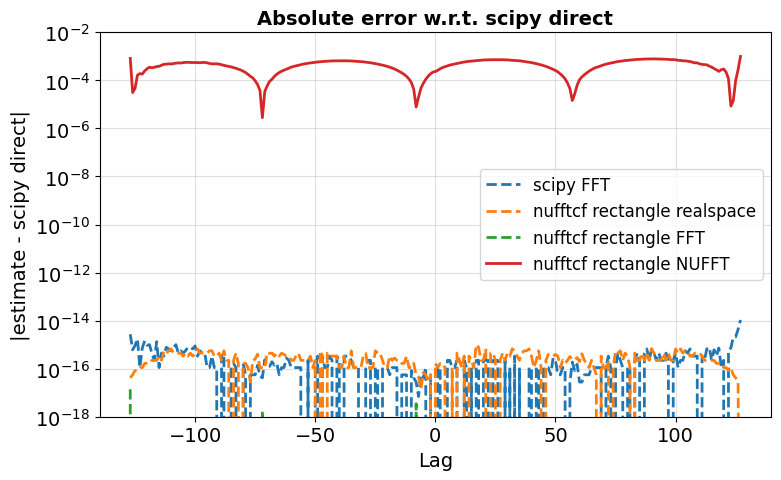

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ls_list = ["--","--","--","-"]


for idx,name in enumerate(list(estimates)):
    err = np.abs(estimates[name] - corr_direct)
    #err = np.where(err > 0, err, np.nan)      # exact zeros cannot be drawn on a log axis
    ax.semilogy(lags, err, lw=2, ls=ls_list[idx], label=name)

ax.set_ylim(1e-18, 1e-2)                     # ignore the few near-zero errors (floating-point noise floor)
ax.set_xlabel('Lag')
ax.set_ylabel('|estimate - scipy direct|')
ax.set_title('Absolute error w.r.t. scipy direct')
ax.grid(which="both", alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

# 6. The `N1` parameter: what's used by default, and how does it affect precision?

`compute_ccf_rectangle_nufft` (and every other `*_nufft` estimator) takes an
optional `N1`, the size of the NUFFT frequency grid. If not given, a default
is chosen automatically -- but since `nufftcf` 0.2.0 that default depends on
the requested `lags`, not just on the series length: the periodic NUFFT
domain is padded to avoid a wrap-around bug at large lags (see the
[CHANGELOG](https://github.com/jecampagne/nufftcf/blob/main/CHANGELOG.md#020---2026-09-19)),
and `N1` is scaled up accordingly. There is no way to know this default
ahead of a call other than asking for it explicitly, with `nufftcf.default_N1`
(added in 0.2.1):

In [ ]:
from nufftcf import default_N1

span = ts.max() - ts.min()
n1_used = default_N1(len(sig), span, lags_f)

print(f"N1 used by default for this call : {n1_used}")
print(f"while a fixed 32*n would give    : {32 * len(sig)}")
print(f"(larger here because lags go up to {lags_f.max():.0f}, a large "
      f"fraction of the {span:.0f}-sample span)")

N1 used by default for this call : 12288
while a fixed 32*n would give    : 4096
(larger here because lags go up to 127, a large fraction of the 127-sample span)


We now sweep `N1` (well below and well above the default) and look at the
same error metric as section 5 (distance to `scipy direct`).

In [ ]:
N1_sweep = sorted(set(np.round(np.geomspace(32, 32 * n1_used, 25)).astype(int)) | {n1_used})

rows_n1 = []
for N1 in N1_sweep:
    c_N1, _ = compute_ccf_rectangle_nufft(lags_f, ts, sig, ts, sig_noise, bin_width=0.5, N1=N1)
    err = np.abs(c_N1 - corr_direct)
    rows_n1.append(dict(N1=N1, max_err=err.max(), rms_err=np.sqrt(np.mean(err**2))))

df_n1 = pd.DataFrame(rows_n1)

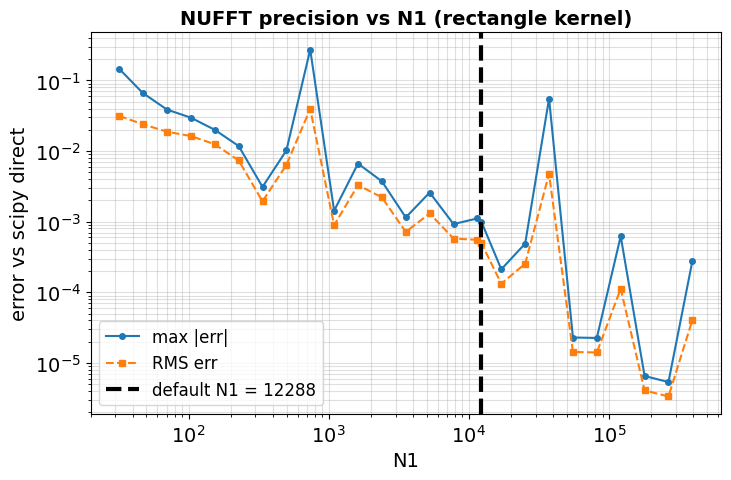

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(df_n1["N1"], df_n1["max_err"], "o-", ms=4, label="max |err|")
ax.loglog(df_n1["N1"], df_n1["rms_err"], "s--", ms=4, label="RMS err")
ax.axvline(n1_used, color="k", ls="--", lw=3, label=f"default N1 = {n1_used}")
ax.set_xlabel("N1")
ax.set_ylabel("error vs scipy direct")
ax.set_title("NUFFT precision vs N1 (rectangle kernel)")
ax.legend()
ax.grid(which="both", alpha=0.4)
fig.tight_layout()
plt.show()


Error decreases **on average** with `N1` -- more Fourier modes generally means a
more faithful reconstruction of the cross-spectrum -- but the curve is **not
monotonic**: a few `N1` values give errors that are orders of magnitude larger than
their neighbors (e.g. `N1 = 32768`, `65536` or `98304`).

In this notebook the
series is regularly sampled (`dt = 1`) and the requested lags are integers. The
NUFFT works on a periodic domain of length
`L = nufftcf.effective_span(span, lags) = span + 2·max|lag|` (here `L = 381`).
Scanning *every* integer `N1` shows that the error depends on how close `N1` is to
a multiple of `L` (`N1 = m·L`, `m` integer). The default `N1` (`12288 = 32.25·L`) is 96 modes away from `32·L`, hence safe here.


**Practical takeaway**: don't hand-pick a specific `N1` hoping it's a "nice"
number, and don't assume a power of 2 is safe. Use `nufftcf.default_N1` (it sits
in a good neighborhood here, `max|err| ~ 1e-3`, consistent with section 5's
summary). If you need more precision, increase `N1` by a large margin rather than
fine-tuning it.

Because a resonance can be hit by chance, **when in doubt test the stability of
your result with respect to `N1`**: recompute the CCF for a handful of neighboring
values (e.g. `N1 - 10 ... N1 + 10`) and check that the results agree. A stable
result is reassuring; a large spread means you are close to a resonance (`N1 ≈ m·L`)
and `N1` should be moved by a few tens of modes. As a final check,  you verify empirically
against `_fft`/`_realspace` on your own data (or a representative subset), exactly
as this notebook does.

# Summary

- **scipy FFT** and **nufftcf rectangle FFT** reproduce the direct sum to machine precision
  (differences of order $10^{-14}$ or below). They are the same estimator, only computed differently.
- **nufftcf rectangle NUFFT** agrees with the direct sum at the $10^{-3}$ level with the default **N1** internal computation. This is far below the
  statistical uncertainty of the estimate (noise $\sigma = 0.2$ on the data), and the position of the peak is unchanged.
- All methods locate the CCF maximum at the same lag (25), consistent with the true (non-integer) delay of 25.6 samples.


The point of `nufftcf` is of course the case where the series are **irregularly sampled** (and possibly sampled
at different times), where `scipy.signal.correlate` cannot be used directly: `compute_ccf_rectangle_nufft` and
`compute_ccf_gaussian_nufft` then apply with the very same call signature. Dedicated notebooks are dealing with theses series for which nufftcf have been designed.